In [1]:
import gc, math
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
from IPython.display import display

import gemlite
from gemlite import DType, GemLiteLinear
from qkernels import (
    awq_preprocess, gemv_kernel, make_wikitext_calib,
    quantize_fp16_to_int4, time_ms, triton_w4a16_gemm,
)

DEVICE = "cuda"
GROUP_SIZE = 128
MODEL_ID = "Qwen/Qwen3-1.7B"
TFLOPS_PEAK = 500.0  # RTX PRO 6000
MEM_BW_GBPS = 1792.0

torch.backends.cuda.matmul.allow_tf32 = False
torch._inductor.config.triton.cudagraph_trees = False
try:
    gemlite.set_autotune("fast")
    gemlite.set_kernel_caching(True)
except AttributeError:
    pass

In [2]:
# Quantization format helpers
def unpack_int4(p):
    lo = (p & 0x0F).to(torch.int8)
    hi = ((p >> 4) & 0x0F).to(torch.int8)
    lo = torch.where(lo >= 8, lo - 16, lo)
    hi = torch.where(hi >= 8, hi - 16, hi)
    out = torch.empty((p.shape[0], p.shape[1] * 2), device=p.device, dtype=torch.int8)
    out[:, 0::2], out[:, 1::2] = lo, hi
    return out


def dequant(packed, scales):
    return unpack_int4(packed).float() * scales.float().repeat_interleave(GROUP_SIZE, dim=1)


def ref_matmul(x, packed, scales):
    return (x.float() @ dequant(packed, scales).T).to(torch.bfloat16)


def _pack_gemlite(packed, scales, in_features, out_features, group_size):
    # signed int4 [-8, 7] -> HQQ unsigned [0, 15] with zero=8.
    w_signed = unpack_int4(packed)
    gl = GemLiteLinear(
        W_nbits=4, group_size=group_size,
        in_features=in_features, out_features=out_features,
        input_dtype=DType.BF16, output_dtype=DType.BF16,
        scaled_activations=False,
    )
    gl.pack((w_signed + 8).to(torch.uint8), scales.to(torch.bfloat16), zeros=8, bias=None)
    return gl

In [3]:
# Quantized linear layers + model swap helpers
class QuantizedLinear(nn.Module):
    """Custom W4A16: triton_w4a16_gemm (M>1) + gemv_kernel (M=1)."""

    def __init__(self, linear, group_size=128):
        super().__init__()
        packed, scales = quantize_fp16_to_int4(
            linear.weight.data.to(torch.float16), group_size,
        )
        self.register_buffer("w_packed", packed)
        self.register_buffer("scales", scales)
        self.register_buffer(
            "bias",
            linear.bias.data.to(torch.bfloat16) if linear.bias is not None else None,
        )
        self.in_features  = linear.in_features
        self.out_features = linear.out_features
        self.group_size = group_size
        self._gemv_ok = self.out_features % 8 == 0

    def forward(self, x):
        shape = x.shape
        x_2d = x.reshape(-1, self.in_features).to(torch.bfloat16)
        if x_2d.shape[0] == 1 and self._gemv_ok:
            y = torch.ops.qkernels_rep.gemv(x_2d, self.w_packed, self.scales, self.group_size)
        else:
            y = torch.ops.qkernels_rep.tgemm(x_2d, self.w_packed, self.scales, self.group_size)
        if self.bias is not None:
            y = y + self.bias
        return y.reshape(*shape[:-1], self.out_features)


class GemliteLinear(nn.Module):
    """Reference W4A16: GemLite, fed our int4 weights and scales."""

    def __init__(self, linear, group_size=128):
        super().__init__()
        packed, scales = quantize_fp16_to_int4(
            linear.weight.data.to(torch.float16), group_size,
        )
        self.gl = _pack_gemlite(
            packed, scales, linear.in_features, linear.out_features, group_size,
        )
        self.register_buffer(
            "bias",
            linear.bias.data.to(torch.bfloat16) if linear.bias is not None else None,
        )
        self.in_features  = linear.in_features
        self.out_features = linear.out_features

    def forward(self, x):
        shape = x.shape
        x_2d = x.reshape(-1, self.in_features).to(torch.bfloat16)
        y = self.gl(x_2d)
        if self.bias is not None:
            y = y + self.bias
        return y.reshape(*shape[:-1], self.out_features)


def _swap_linears(model, linear_cls, group_size, skip):
    targets = []
    for parent_name, module in model.named_modules():
        for child_name, child in module.named_children():
            if not isinstance(child, nn.Linear):
                continue
            full = f"{parent_name}.{child_name}" if parent_name else child_name
            if any(full == s or full.endswith("." + s) for s in skip):
                continue
            if child.in_features % group_size == 0:
                targets.append((module, child_name, child))
    for parent, name, layer in targets:
        setattr(parent, name, linear_cls(layer, group_size))
    torch.cuda.empty_cache()
    return len(targets)


def quantize_model(model, group_size=128, skip=()):
    return _swap_linears(model, QuantizedLinear, group_size, skip)


def swap_with_gemlite(model, group_size=128, skip=()):
    return _swap_linears(model, GemliteLinear, group_size, skip)


def load_bf16():
    return AutoModelForCausalLM.from_pretrained(
        MODEL_ID, torch_dtype=torch.bfloat16, device_map=DEVICE,
    ).eval()

In [4]:
# Roofline + bench helpers (graphed)
_QUANT_CLASSES = ("QuantizedLinear", "GemliteLinear")


def collect_linear_shapes(model, skip=("lm_head",)):
    shapes = []
    for name, m in model.named_modules():
        if name.split(".")[-1] in skip:
            continue
        if isinstance(m, nn.Linear):
            shapes.append((name, m.out_features, m.in_features, False))
        elif (m.__class__.__name__ in _QUANT_CLASSES
              and getattr(m, "in_features", None) is not None):
            shapes.append((name, m.out_features, m.in_features, True))
    return shapes


def matmul_flops_per_token(shapes):
    return sum(2.0 * n * k for _, n, k, _ in shapes)


def weight_bytes_per_pass(shapes, kernel_type, group_size=GROUP_SIZE):
    tot = 0.0
    for _, n, k, is_q in shapes:
        if kernel_type == "bf16" or not is_q:
            tot += 2.0 * n * k
        else:
            tot += 0.5 * n * k + 2.0 * (k / group_size) * n
    return tot


def activation_bytes_per_pass(shapes, m_tokens):
    return sum(2.0 * m_tokens * k + 2.0 * m_tokens * n for _, n, k, _ in shapes)


def roofline_metrics(median_ms, flops, bytes_total):
    s = median_ms / 1e3
    tflops = flops / s / 1e12
    gbs = bytes_total / s / 1e9
    return {
        "TFLOP/s": round(tflops, 1),
        "GB/s": round(gbs, 1),
        "pct_TC_peak": round(100.0 * tflops / TFLOPS_PEAK, 1),
        "pct_BW_peak": round(100.0 * gbs / MEM_BW_GBPS, 1),
    }


@torch.no_grad()
def perplexity(model, tokenizer, max_length=2048):
    test = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    enc = tokenizer("\n\n".join(test["text"]), return_tensors="pt")
    seq_len = enc.input_ids.size(1)
    nll, ntok, prev = 0.0, 0, 0
    for start in tqdm(range(0, seq_len, max_length), desc="ppl"):
        end = min(start + max_length, seq_len)
        trg = end - prev
        ids = enc.input_ids[:, start:end].to(DEVICE)
        labels = ids.clone(); labels[:, :-trg] = -100
        nll += model(ids, labels=labels, use_cache=False).loss.item() * trg
        ntok += trg
        prev = end
        if end == seq_len:
            break
    return math.exp(nll / ntok)


@torch.no_grad()
def _warmup_shapes(model, ids_list, n=2):
    for ids in ids_list:
        for _ in range(n):
            model(ids, use_cache=False)
    torch.cuda.synchronize()


@torch.no_grad()
def bench_prefill(model, seq_len, shapes, kernel_type, *, warmup=10, repeats=50):
    ids = torch.randint(100, 10000, (1, seq_len), device=DEVICE)
    t = time_ms(
        lambda: model(ids, use_cache=False),
        warmup=warmup, repeats=repeats,
    )
    flops   = matmul_flops_per_token(shapes) * seq_len
    a_bytes = activation_bytes_per_pass(shapes, seq_len)
    w_bytes = weight_bytes_per_pass(shapes, kernel_type)
    return {
        "seq_len": seq_len,
        "ms": round(t["median_ms"], 2),
        "min_ms": round(t["min_ms"], 2),
        "iqr_ms": round(t["iqr_ms"], 2),
        **roofline_metrics(t["median_ms"], flops, w_bytes + a_bytes),
    }


@torch.no_grad()
def bench_decode(model, tokenizer, shapes, kernel_type, *,
                 prompt="Once upon a time", new_tokens=64,
                 warmup=3, repeats=20):
    ids = tokenizer(prompt, return_tensors="pt").input_ids.to(DEVICE)
    ttft = time_ms(
        lambda: model(ids, use_cache=False),
        warmup=warmup, repeats=repeats,
    )["median_ms"]
    kw = dict(max_new_tokens=new_tokens, min_new_tokens=new_tokens,
              use_cache=True, do_sample=False,
              pad_token_id=tokenizer.eos_token_id,
              cache_implementation="static")
    total = time_ms(
        lambda: model.generate(ids, **kw),
        warmup=warmup, repeats=repeats,
    )["median_ms"]
    tpot = (total - ttft) / (new_tokens - 1)
    flops = matmul_flops_per_token(shapes)
    w_bytes = weight_bytes_per_pass(shapes, kernel_type)
    a_bytes = activation_bytes_per_pass(shapes, 1)
    return {
        "ttft_ms": round(ttft, 2),
        "tpot_ms": round(tpot, 3),
        "tok_s": round(new_tokens / (total / 1000.0), 1),
        **roofline_metrics(tpot, flops, w_bytes + a_bytes),
    }


def measure_speed(model, tokenizer, kernel_type, *, seq_lens=(128, 512, 2048)):
    shapes = collect_linear_shapes(model, skip=("lm_head",))
    _warmup_shapes(model, [torch.randint(100, 10000, (1, s), device=DEVICE) for s in seq_lens])
    prefill_rows = [{"kernel_type": kernel_type, **bench_prefill(model, s, shapes, kernel_type)} for s in seq_lens]
    decode_row = {"kernel_type": kernel_type, **bench_decode(model, tokenizer, shapes, kernel_type)}
    return prefill_rows, decode_row

In [11]:
# torch.compile registration
import quant_kernels_cuda

try:
    @torch.library.custom_op("qkernels_rep::gemv", mutates_args=())
    def _gemv(x: torch.Tensor, w: torch.Tensor, s: torch.Tensor, g: int) -> torch.Tensor:
        return quant_kernels_cuda.gemv_kernel(x, w, s, g)
    @_gemv.register_fake
    def _gemv_fake(x, w, s, g):
        return torch.empty((x.shape[0], w.shape[0]), device=x.device, dtype=torch.bfloat16)

    @torch.library.custom_op("qkernels_rep::tgemm", mutates_args=())
    def _tgemm(x: torch.Tensor, w: torch.Tensor, s: torch.Tensor, g: int) -> torch.Tensor:
        return triton_w4a16_gemm(x, w, s, g)
    @_tgemm.register_fake
    def _tgemm_fake(x, w, s, g):
        return torch.empty((x.shape[0], w.shape[0]), device=x.device, dtype=torch.bfloat16)
except RuntimeError:
    pass

torch._dynamo.config.recompile_limit = 64
torch._dynamo.config.allow_unspec_int_on_nn_module = True


def _reset_compile_state():
    import torch._dynamo
    import torch._inductor
    torch._dynamo.reset()
    for path in (("codecache", "PyCodeCache", "cache_clear"),
                 ("utils", "clear_inductor_caches")):
        obj = torch._inductor
        for attr in path:
            obj = getattr(obj, attr, None)
            if obj is None:
                break
        if callable(obj):
            obj()


def measure_speed_graphed(model, tokenizer, kernel_type):
    _reset_compile_state()
    compiled = torch.compile(model, mode="reduce-overhead", fullgraph=False)
    return measure_speed(compiled, tokenizer, kernel_type)

In [6]:
# Unit tests: quantizer round-trip, triton GEMM, custom GEMV
torch.manual_seed(0)
W = torch.randn(64, 1024, device=DEVICE, dtype=torch.float16)
packed, scales = quantize_fp16_to_int4(W, group_size=GROUP_SIZE)
err = dequant(packed, scales) - W.float()
assert packed.shape == (64, 512) and packed.dtype == torch.uint8
assert scales.shape == (64, 8) and scales.dtype == torch.float16
assert err.pow(2).mean().item() < 0.02

# triton W4A16 vs cuBLAS bf16 on dequantized weights, across M.
torch.manual_seed(1)
w_t = torch.randn(2048, 2048, device=DEVICE, dtype=torch.float16)
wp_t, sc_t = quantize_fp16_to_int4(w_t, group_size=GROUP_SIZE)
w_dq = dequant(wp_t, sc_t).to(torch.bfloat16)
for M in (1, 128, 2048):
    x_t = torch.randn(M, 2048, device=DEVICE, dtype=torch.bfloat16)
    y_ref = x_t @ w_dq.T
    y_triton = triton_w4a16_gemm(x_t, wp_t, sc_t, group_size=GROUP_SIZE)
    rel = (y_ref.float() - y_triton.float()).abs().max().item() / y_ref.float().abs().max().item()
    assert rel < 1e-2, (M, rel)

# Custom GEMV per Qwen3-1.7B decode shape, plus alignment rejection.
torch.manual_seed(11)
for N, K in [(2048, 2048), (1024, 2048), (6144, 2048), (2048, 6144)]:
    x1 = torch.randn(1, K, device=DEVICE, dtype=torch.bfloat16)
    w = torch.randn(N, K, device=DEVICE, dtype=torch.float16)
    wp, sc = quantize_fp16_to_int4(w, group_size=GROUP_SIZE)
    y_gemv = gemv_kernel(x1, wp, sc, group_size=GROUP_SIZE)
    y_ref = ref_matmul(x1, wp, sc)
    rel = (y_gemv.float() - y_ref.float()).abs().max().item() / y_ref.float().abs().max().item()
    assert rel < 1e-2, (N, K, rel)

bad_K = 128
x = torch.randn(1, bad_K, device=DEVICE, dtype=torch.bfloat16)
w = torch.randn(256, bad_K, device=DEVICE, dtype=torch.float16)
wp, sc = quantize_fp16_to_int4(w, group_size=GROUP_SIZE)
try:
    gemv_kernel(x, wp, sc, group_size=GROUP_SIZE)
    raise AssertionError(f"gemv_kernel accepted K={bad_K}")
except RuntimeError as e:
    assert "divisible by 1024" in str(e), str(e)

print("Unit tests passed.")

Unit tests passed.


In [7]:
# Per-shape kernel microbench: bf16 vs custom triton vs custom GEMV vs gemlite.
shapes_mb = [
    ("q/o_proj", 2048, 2048),
    ("k/v_proj", 1024, 2048),
    ("gate/up_proj", 6144, 2048),
    ("down_proj", 2048, 6144),
    ("lm_head", 151936, 2048),
]


def _us_pair(fn):
    t = time_ms(fn, warmup=25, repeats=20, batch=32)
    return round(t["median_ms"] * 1e3, 1), round(t["min_ms"] * 1e3, 1)


def _check_rel(y, y_ref, label, tol=1e-2):
    rel = (y.float() - y_ref.float()).abs().max().item() / y_ref.float().abs().max().item()
    assert rel < tol, (label, rel)


rows = []
for layer, N, K in shapes_mb:
    torch.manual_seed(42)
    w_bf16 = torch.randn(N, K, device=DEVICE, dtype=torch.bfloat16)
    wp, sc = quantize_fp16_to_int4(w_bf16.to(torch.float16), group_size=GROUP_SIZE)
    gl = _pack_gemlite(wp, sc, K, N, GROUP_SIZE)
    for M in (1, 128, 512, 2048):
        x = torch.randn(M, K, device=DEVICE, dtype=torch.bfloat16)
        y_ref = triton_w4a16_gemm(x, wp, sc, group_size=GROUP_SIZE)
        _check_rel(gl(x), y_ref, (layer, M, "gemlite"))
        if M == 1:
            _check_rel(gemv_kernel(x, wp, sc, group_size=GROUP_SIZE), y_ref, (layer, M, "gemv"))

        bf16_us, bf16_min = _us_pair(lambda: torch.matmul(x, w_bf16.T))
        triton_us, trit_min = _us_pair(lambda: triton_w4a16_gemm(x, wp, sc, group_size=GROUP_SIZE))
        gl_us, gl_min = _us_pair(lambda: gl(x))
        if M == 1:
            gemv_us, gemv_min = _us_pair(lambda: gemv_kernel(x, wp, sc, group_size=GROUP_SIZE))
        else:
            gemv_us = gemv_min = None

        rows.append({
            "layer": layer, "shape": f"{N}x{K}", "M": M,
            "bf16_us": bf16_us, "bf16_min_us": bf16_min,
            "triton_us": triton_us, "triton_min_us": trit_min,
            "gemv_kernel_us": gemv_us, "gemv_min_us": gemv_min,
            "gemlite_us": gl_us, "gemlite_min_us": gl_min,
        })

microbench_df = pd.DataFrame(rows)

In [8]:
# Quality: BF16 vs INT4 RTN vs INT4 AWQ on WikiText-2 perplexity
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = load_bf16()
ppl_bf16 = perplexity(model, tokenizer)

del model; gc.collect(); torch.cuda.empty_cache()
model = load_bf16()
quantize_model(model, group_size=GROUP_SIZE, skip=("lm_head",))
ppl_rtn = perplexity(model, tokenizer)

del model; gc.collect(); torch.cuda.empty_cache()
model = load_bf16()
calib_ids = make_wikitext_calib(tokenizer, n_samples=16, seq_len=512)
awq_preprocess(model, calib_ids, group_size=GROUP_SIZE)
quantize_model(model, group_size=GROUP_SIZE, skip=("lm_head",))
ppl_awq = perplexity(model, tokenizer)

quality_df = pd.DataFrame([
    {"variant": "BF16", "perplexity": round(ppl_bf16, 2)},
    {"variant": "INT4 RTN", "perplexity": round(ppl_rtn, 2)},
    {"variant": "INT4 AWQ", "perplexity": round(ppl_awq, 2)},
])

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (299078 > 131072). Running this sequence through the model will result in indexing errors


ppl:   0%|          | 0/147 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

ppl:   0%|          | 0/147 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

ppl:   0%|          | 0/147 [00:00<?, ?it/s]

In [9]:
# Through-model correctness: bf16 and custom decode logits should agree.
_probe_ids = tokenizer("Once upon a time, in a small village,",
                       return_tensors="pt").input_ids.to(DEVICE)


@torch.no_grad()
def _prefill_then_one_decode_step(m):
    pref = m(_probe_ids, use_cache=True)
    next_tok = pref.logits[:, -1, :].argmax(dim=-1, keepdim=True)
    dec = m(next_tok, past_key_values=pref.past_key_values, use_cache=True)
    return dec.logits[:, -1, :].float().cpu(), int(next_tok)


del model; gc.collect(); torch.cuda.empty_cache()
m_bf = load_bf16()
bf_logits, bf_tok = _prefill_then_one_decode_step(m_bf)

del m_bf; gc.collect(); torch.cuda.empty_cache()
m_q = load_bf16()
n_q = quantize_model(m_q, group_size=GROUP_SIZE, skip=("lm_head",))
q_logits, q_tok = _prefill_then_one_decode_step(m_q)

cos = torch.nn.functional.cosine_similarity(
    bf_logits.flatten(), q_logits.flatten(), dim=0,
).item()
print(f"n_quant={n_q}  bf16_tok={bf_tok}  custom_tok={q_tok}  cos={cos:.4f}")
assert cos > 0.80
assert int(bf_logits.argmax(-1)) == int(q_logits.argmax(-1))

del m_q; gc.collect(); torch.cuda.empty_cache()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

n_quant=196  bf16_tok=1052  custom_tok=1052  cos=0.9175


In [12]:
# Speed: torch.compile(reduce-overhead) + static KV cache, all kernel_types.
prefill_rows, decode_rows = [], []

model = load_bf16()
p, d = measure_speed_graphed(model, tokenizer, kernel_type="bf16")
prefill_rows += p; decode_rows.append(d)

del model; gc.collect(); torch.cuda.empty_cache()
model = load_bf16()
quantize_model(model, group_size=GROUP_SIZE, skip=("lm_head",))
p, d = measure_speed_graphed(model, tokenizer, kernel_type="custom")
prefill_rows += p; decode_rows.append(d)

del model; gc.collect(); torch.cuda.empty_cache()
model = load_bf16()
swap_with_gemlite(model, group_size=GROUP_SIZE, skip=("lm_head",))
p, d = measure_speed_graphed(model, tokenizer, kernel_type="gemlite")
prefill_rows += p; decode_rows.append(d)

prefill_df = pd.DataFrame(prefill_rows)
decode_df = pd.DataFrame(decode_rows)
# display(prefill_df)
# display(decode_df)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
# Column headers names meaning:


# Microbench
# _us — median time.
# _min_us — best time.


# Prefill (full-model forward, milliseconds + roofline):
# ms — median end-to-end latency for one forward at the given seq_len.
# min_ms — best run.
# iqr_ms — interquartile range across runs.
# TFLOP/s — matmul FLOPs / time.
# GB/s — weight + activation + output bytes / time.
# pct_TC_peak — % of dense bf16 Tensor Core peak (500 TFLOP/s).
# pct_BW_peak — % of HBM peak (1792 GB/s).


# Decode (autoregressive generation, milliseconds + tokens/sec + roofline):
# ttft_ms — Time To First Token.
# tpot_ms — Time Per Output Token, average time per generated decode step after the prefill.
# tok_s — overall throughput (new_tokens / total_time).
# TFLOP/s — per-token FLOPs / TPOT.
# GB/s — achieved memory bandwidth at decode.
# pct_TC_peak — % of dense bf16 TC peak (decode never touches Tensor Cores by design).
# pct_BW_peak — % of HBM peak.

In [13]:
# Consolidated report
print("PPL")
display(quality_df)

print("\nPer-shape kernel microbench (us, batched-launch)")
display(microbench_df)

print("\nPrefill")
display(prefill_df)

print("\nDecode")
display(decode_df)

PPL


,variant,perplexity
0,BF16,16.72
1,INT4 RTN,22.69
2,INT4 AWQ,17.76



Per-shape kernel microbench (us, batched-launch)


,layer,shape,M,bf16_us,bf16_min_us,triton_us,triton_min_us,gemv_kernel_us,gemv_min_us,gemlite_us,gemlite_min_us
0,q/o_proj,2048x2048,1,8.4,8.4,21.1,21.0,10.3,10.3,56.9,56.0
1,q/o_proj,2048x2048,128,16.6,16.6,25.1,25.1,NaN,NaN,52.2,51.5
2,q/o_proj,2048x2048,512,26.8,26.6,39.6,37.4,NaN,NaN,53.0,52.3
3,q/o_proj,2048x2048,2048,67.9,67.9,105.4,105.2,NaN,NaN,75.5,75.3
4,k/v_proj,1024x2048,1,8.3,8.3,21.0,20.9,6.2,6.2,56.8,56.1
5,k/v_proj,1024x2048,128,12.5,12.5,21.1,21.1,NaN,NaN,51.5,50.9
6,k/v_proj,1024x2048,512,24.8,24.8,27.2,27.2,NaN,NaN,51.7,51.2
7,k/v_proj,1024x2048,2048,33.0,33.0,60.1,59.7,NaN,NaN,52.3,51.9
8,gate/up_proj,6144x2048,1,22.5,22.2,21.0,20.9,20.6,20.5,57.6,57.2
9,gate/up_proj,6144x2048,128,20.7,20.7,37.5,37.4,NaN,NaN,52.4,51.9



Prefill


,kernel_type,seq_len,ms,min_ms,iqr_ms,TFLOP/s,GB/s,pct_TC_peak,pct_BW_peak
0,bf16,128,5.31,5.09,0.02,68.0,583.7,13.6,32.6
1,bf16,512,10.98,10.97,0.01,131.4,358.3,26.3,20.0
2,bf16,2048,38.51,38.45,0.02,149.9,189.1,30.0,10.6
3,custom,128,7.75,7.59,0.01,46.5,129.7,9.3,7.2
4,custom,512,14.65,14.62,0.01,98.5,125.8,19.7,7.0
5,custom,2048,50.79,50.67,0.02,113.6,102.2,22.7,5.7
6,gemlite,128,6.17,6.06,0.01,58.4,162.9,11.7,9.1
7,gemlite,512,12.46,12.44,0.01,115.8,147.8,23.2,8.2
8,gemlite,2048,39.78,39.71,0.03,145.1,130.4,29.0,7.3



Decode


,kernel_type,ttft_ms,tpot_ms,tok_s,TFLOP/s,GB/s,pct_TC_peak,pct_BW_peak
0,bf16,5.12,6.251,160.4,0.5,451.2,0.1,25.2
1,custom,7.72,3.673,267.7,0.8,198.4,0.2,11.1
2,gemlite,3.99,5.398,186.0,0.5,135.0,0.1,7.5


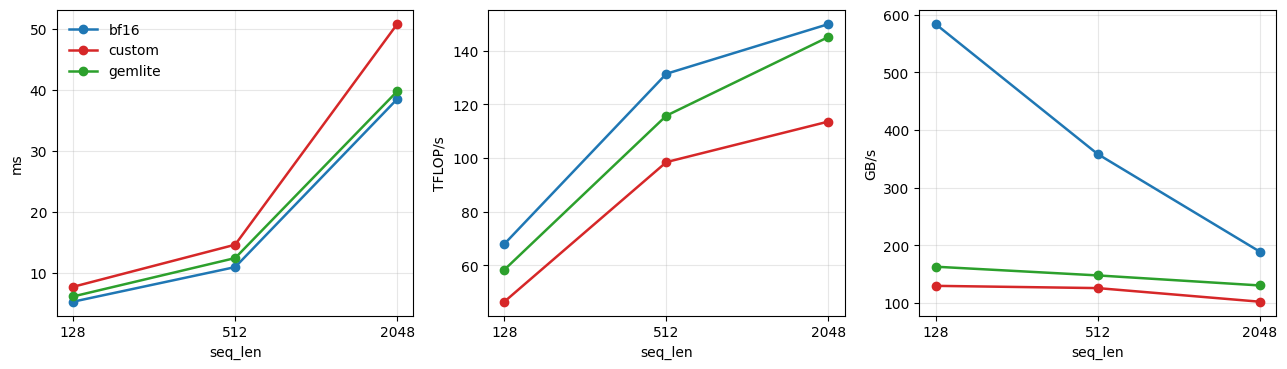

In [14]:
# Prefill chart: latency, compute throughput, memory bandwidth
COLORS = {"bf16": "#1f77b4", "custom": "#d62728", "gemlite": "#2ca02c"}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col in zip(axes, ("ms", "TFLOP/s", "GB/s")):
    for kernel_type in ("bf16", "custom", "gemlite"):
        sub = prefill_df[prefill_df["kernel_type"] == kernel_type].sort_values("seq_len")
        ax.plot(sub["seq_len"], sub[col], marker="o",
                color=COLORS[kernel_type], linewidth=1.8, label=kernel_type)
    ax.set_xscale("log", base=2)
    ax.set_xticks([128, 512, 2048]); ax.set_xticklabels([128, 512, 2048])
    ax.set_xlabel("seq_len"); ax.set_ylabel(col); ax.grid(alpha=0.3)
axes[0].legend(frameon=False)
plt.tight_layout(); plt.show()